<a href="https://colab.research.google.com/github/rebeca07-pedrozo/DATA-MARKET/blob/main/DATA_MARKET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instalacion de dependencias


In [ ]:
!pip install pyECLAT gspread mlxtend openpyxl plotly --quiet
# pyECLAT : implementacion del algoritmo con soporte y reglas incluidos
# gspread : cliente Python para Google Sheets API
# mlxtend : metricas adicionales de reglas (conviction, leverage)

# Imports, paleta de colores y configuración global

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pyECLAT import ECLAT
from mlxtend.frequent_patterns import association_rules as mlx_rules
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

PALETTE = {
    'primary'  : '#C84410',
    'secondary': '#1A1A2E',
    'accent'   : '#AEECEF',
    'gold'     : '#F5A623',
    'success'  : '#2ECC71',
    'muted'    : '#7F8C8D',
}


CAT_MAP = {
    'Frescos'     : ['Carne','Cerdo','Pollo','Pescado','Leche','Queso',
                     'Frutas','Verduras'],
    'Basicos'     : ['Arroz','Pasta','Harina','Papa','Platano','Huevos',
                     'Azucar','Sal','Panela','Aceite','Yuca'],
    'Despensa'    : ['Cafe','Chocolate','Frijol','Lentejas','Pan',
                     'Mantequilla','Galletas','Dulces','Jugos','Agua'],
    'Delikatessen': ['Aceitunas','Carnes maduras','Quesos especiales',
                     'Vinos/Licores','Productos importados'],
    'Aseo'        : ['Jabon de bano','Champu','Acondicionador',
                     'Detergente en polvo / liquido','Lavaloza',
                     'Papel higienico','Crema dental','Desodorante',
                     'Seda dental','Enjuague bucal','Suavizante'],
}
CAT_COLORS = {
    'Frescos'     : '#E63946',
    'Basicos'     : '#457B9D',
    'Despensa'    : '#2A9D8F',
    'Delikatessen': '#E9C46A',
    'Aseo'        : '#8338EC',
}
ITEM_COLOR = {item: CAT_COLORS[cat]
              for cat, items in CAT_MAP.items() for item in items}

def get_item_category(item):
    for cat, items in CAT_MAP.items():
        if item in items:
            return cat
    return 'Otro'

CANAL_LABELS = {
    'Canal_Hard'   : 'Hard Discount',
    'Canal_Grandes': 'Grandes Superficies',
    'Canal_Tienda' : 'Tienda de Barrio',
    'Canal_Plaza'  : 'Plaza de Mercado',
    'Canal_App'    : 'App / Domicilios',
}

#   MIN_SUPPORT ≥ 5 / N ,no  confiamos en patrones que aparecen muy pocas veces”
MIN_SUPPORT     = 0.30   #Soporte: una combinación de productos debe aparecer en al menos el 30% de los hogares
MIN_CONFIDENCE  = 0.60   # Confianza: De los que compran A, el 60% también compra B
MAX_COMBINATION = 3      # Tripletes máximo 3 (A, B, C)
SEPARATOR       = ' & '  # Separador interno de pyECLAT

plt.rcParams.update({
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : '#FAFAFA',
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'font.family'        : 'DejaVu Sans',
    'axes.titlesize'     : 14,
    'axes.titleweight'   : 'bold',
    'axes.labelsize'     : 11,
    'xtick.labelsize'    : 9,
    'ytick.labelsize'    : 9,
    'legend.fontsize'    : 9,
})


# Conexión directa a Google Sheets

**El pipeline de datos sigue la arquitectura Medallion:**

1. Bronze: Forms raw
2. Silver: hoja 'limpieza' (ETL realizado en Apps Script)
3. Gold: resultados de ECLAT (este notebook)




In [ ]:
from google.colab import auth
from google.auth import default
import gspread

auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

SHEET_URL  = 'https://docs.google.com/spreadsheets/d/1I25vlgcHIgBXAaDZA_Hj0ntBMheT5STA7K0CCU0RLe0/edit?gid=884482377#gid=884482377'
SHEET_NAME = 'limpieza'

spreadsheet = gc.open_by_url(SHEET_URL)
worksheet   = spreadsheet.worksheet(SHEET_NAME)
print(f"Listis → '{spreadsheet.title}' | hoja '{SHEET_NAME}'")

Listis → 'DATA-MARKET (Respuestas)' | hoja 'limpieza'


# Parsing y separación por capas lógicas

**Contamos con 3 capas lógicas**
1. df_prod: matriz one-hot de productos (para el ECLAT)
2. df_meta: variables demográficas (para la segmentación)
3. df_canal: canales de compra (para el análisis cruzado)

In [ ]:
records = worksheet.get_all_records()
df_raw  = pd.DataFrame(records)

# Detectar columnas por prefijo
PROD_COLS  = [c for c in df_raw.columns if c.startswith('Prod_')]
CANAL_COLS = [c for c in df_raw.columns if c.startswith('Canal_')]
META_COLS  = ['Genero', 'Edad', 'Ciudad_Normalizada', 'Estrato',
              'Hogar_Size', 'Responsabilidad', 'Presupuesto', 'Frecuencia']

# Mirar que las columnas si existan de verdad
META_COLS  = [c for c in META_COLS if c in df_raw.columns]

df_prod  = df_raw[PROD_COLS].copy().astype(int)
df_meta  = df_raw[META_COLS].copy()
df_canal = df_raw[CANAL_COLS].copy().astype(int)
df_full  = pd.concat([df_meta, df_prod, df_canal], axis=1).reset_index(drop=True)

prod_names = [c.replace('Prod_', '') for c in PROD_COLS]
N = len(df_raw)

# Check rapido
print("=" * 55)
print("  SILVER LAYER — RESUMEN DE INTEGRIDAD")
print("=" * 55)
print(f"  Encuestados          : {N}")
print(f"  Productos rastreados : {len(PROD_COLS)}")
print(f"  Canales de compra    : {len(CANAL_COLS)}")
print(f"  Variables demográf.  : {len(META_COLS)}")
print(f"  Valores nulos (total): {df_raw.isnull().sum().sum()}")
print("=" * 55)
display(df_raw.head(3))

  SILVER LAYER — RESUMEN DE INTEGRIDAD
  Encuestados          : 200
  Productos rastreados : 45
  Canales de compra    : 5
  Variables demográf.  : 8
  Valores nulos (total): 0


,Timestamp,Genero,Edad,Ciudad_Normalizada,Estrato,Hogar_Size,Responsabilidad,Presupuesto,Frecuencia,Motivacion_General,...,Prod_Champú,Prod_Acondicionador,Prod_Detergente en polvo / líquido,Prod_Lavaloza,Prod_Papel higiénico,Prod_Crema dental,Prod_Desodorante,Prod_Seda dental,Prod_Enjuague bucal,Prod_Suavizante
0,19/4/2026,Masculino,25 – 34,Bogotá,2,1 (Vivo solo/a),Individual,Menos de $500.000 COP,Diario,Necesidad: Solo lo estrictamente básico para e...,...,0,0,1,0,1,1,0,0,0,0
1,19/4/2026,Femenino,18 – 24,Bogotá,3,2 a 4 personas,Compartida,$500.000 - $1.000.000 COP,Quincenal,Necesidad: Solo lo estrictamente básico para e...,...,1,0,1,1,1,1,1,0,0,0
2,19/4/2026,Femenino,35 – 44,Bogotá,2,2 a 4 personas,Individual,$500.000 - $1.000.000 COP,Quincenal,Necesidad: Solo lo estrictamente básico para e...,...,0,0,1,0,1,1,0,0,0,0


# EDA Demográfico


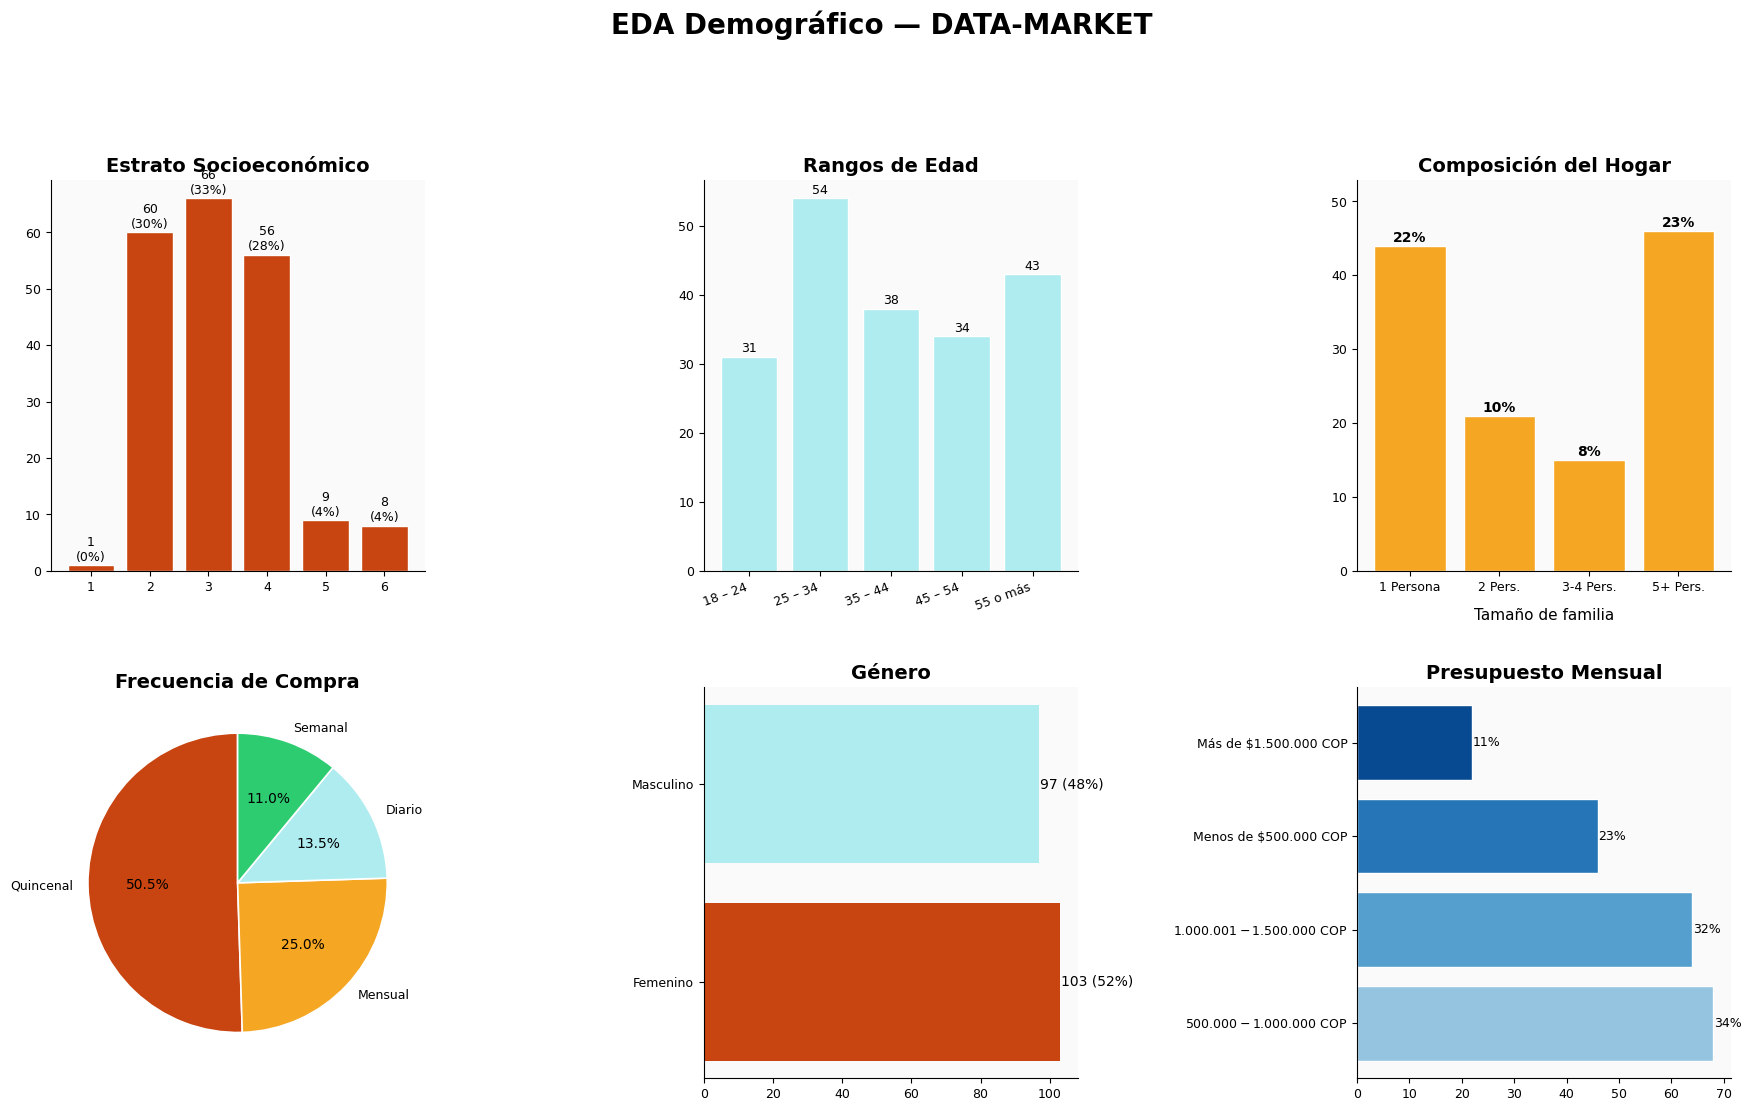

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('EDA Demográfico — DATA-MARKET', fontsize=20, fontweight='bold', y=1.03)

# 1. Estrato
ax = axes[0, 0]
estrato_vc = df_meta['Estrato'].value_counts().sort_index()
bars = ax.bar(estrato_vc.index.astype(str), estrato_vc.values, color=PALETTE['primary'], edgecolor='white')
for b, v in zip(bars, estrato_vc.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.3, f'{v}\n({v/N:.0%})', ha='center', va='bottom', fontsize=9)
ax.set_title('Estrato Socioeconómico')

# 2. Edad
ax = axes[0, 1]
edad_vc = df_meta['Edad'].value_counts().sort_index()
bars = ax.bar(edad_vc.index.astype(str), edad_vc.values, color=PALETTE['accent'], edgecolor='white')
for b, v in zip(bars, edad_vc.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.3, f'{v}', ha='center', va='bottom', fontsize=9)
ax.set_title('Rangos de Edad')
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

# 3. Tamaño del Hogar
ax = axes[0, 2]
map_hogar = {
    '1 (Vivo solo/a)': '1 Persona',
    '2 personas': '2 Pers.',
    '3 a 4 personas': '3-4 Pers.',
    '5 o más personas': '5+ Pers.'
}
hogar_clean = df_meta['Hogar_Size'].replace(map_hogar)
orden_hogar = ['1 Persona', '2 Pers.', '3-4 Pers.', '5+ Pers.']
hogar_vc = hogar_clean.value_counts().reindex(orden_hogar).dropna()

bars = ax.bar(hogar_vc.index.astype(str), hogar_vc.values, color=PALETTE['gold'], edgecolor='white')
for i, v in enumerate(hogar_vc.values):
    ax.text(i, v + 0.15, f'{v/N:.0%}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Composición del Hogar')
ax.set_xlabel('Tamaño de familia', labelpad=10)
ax.set_ylim(0, hogar_vc.max() * 1.15)

# 4. Frecuencia
ax = axes[1, 0]
freq_vc = df_meta['Frecuencia'].value_counts()
ax.pie(freq_vc.values, labels=freq_vc.index, autopct='%1.1f%%', startangle=90,
       colors=[PALETTE['primary'], PALETTE['gold'], PALETTE['accent'], PALETTE['success'], PALETTE['muted']],
       wedgeprops={'edgecolor': 'white', 'linewidth': 1.2})
ax.set_title('Frecuencia de Compra')

# 5. Género
ax = axes[1, 1]
gen_vc = df_meta['Genero'].value_counts()
ax.barh(gen_vc.index, gen_vc.values, color=[PALETTE['primary'], PALETTE['accent']])
for i, v in enumerate(gen_vc.values):
    ax.text(v + 0.2, i, f'{v} ({v/N:.0%})', va='center', fontsize=10)
ax.set_title('Género')

# 6. Presupuesto
ax = axes[1, 2]
pres_vc = df_meta['Presupuesto'].value_counts()
colors_pres = plt.cm.Blues(np.linspace(0.4, 0.9, len(pres_vc)))
ax.barh(pres_vc.index, pres_vc.values, color=colors_pres, edgecolor='white')
for i, v in enumerate(pres_vc.values):
    ax.text(v + 0.1, i, f'{v/N:.0%}', va='center', fontsize=9)
ax.set_title('Presupuesto Mensual')

plt.tight_layout(pad=3.0)
plt.savefig('eda_demografico_final.png', dpi=200, bbox_inches='tight')
plt.show()

# EDA de Canales de Compra
Un hogar puede usar múltiples canales (variable multivaluada binaria).
Este bloque responde:
1. ¿Cuál canal domina en penetración?
2. ¿Cuántos canales usa un hogar en promedio?
3. ¿Existen combinaciones de canales frecuentes?

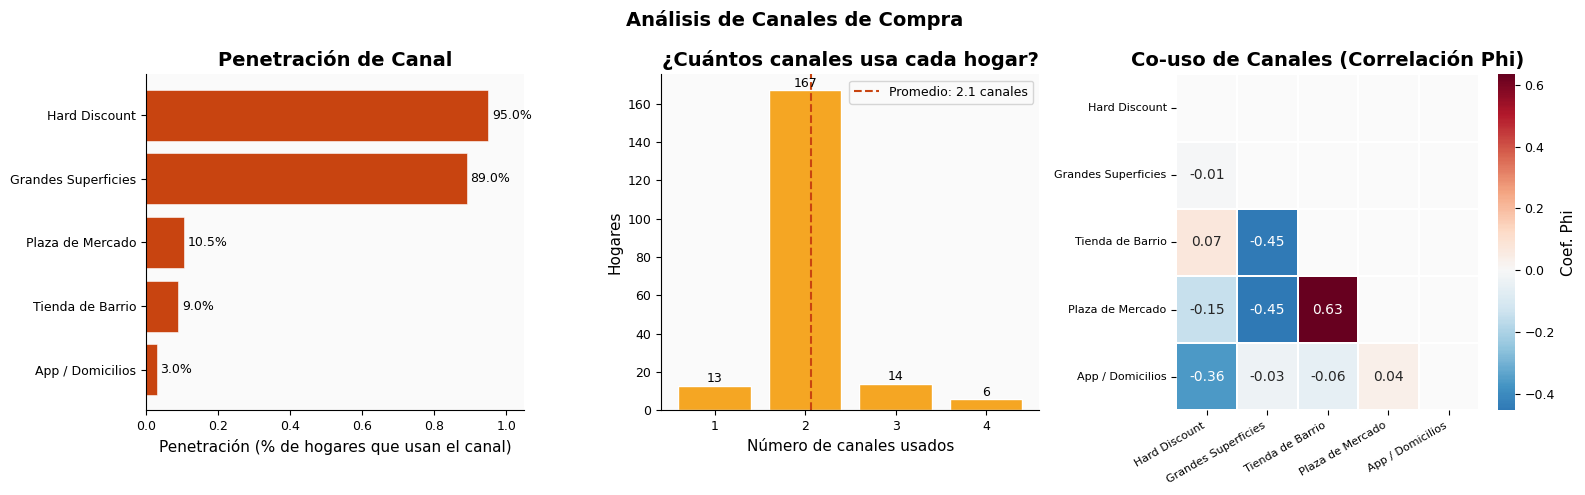

 Promedio de canales por hogar: 2.06
   Canal dominante: Hard Discount (95.0%)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Análisis de Canales de Compra', fontsize=14, fontweight='bold')

# Penetración por canal
ax = axes[0]
canal_pen = df_canal.mean().sort_values(ascending=False)
canal_pen.index = [CANAL_LABELS.get(c, c) for c in canal_pen.index]
bars = ax.barh(canal_pen.index[::-1], canal_pen.values[::-1],
               color=PALETTE['primary'], edgecolor='white', linewidth=0.4)
for bar, val in zip(bars, canal_pen.values[::-1]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=9)
ax.set_xlabel('Penetración (% de hogares que usan el canal)')
ax.set_title('Penetración de Canal')
ax.set_xlim(0, 1.05)

# Número de canales usados por hogar
ax = axes[1]
canales_por_hogar = df_canal.sum(axis=1)
canal_dist = canales_por_hogar.value_counts().sort_index()
ax.bar(canal_dist.index.astype(str), canal_dist.values,
       color=PALETTE['gold'], edgecolor='white')
ax.axvline(x=canales_por_hogar.mean() - 1,  # ajuste de índice
           color=PALETTE['primary'], linestyle='--', lw=1.5,
           label=f'Promedio: {canales_por_hogar.mean():.1f} canales')
for i, v in enumerate(canal_dist.values):
    ax.text(i, v + 0.1, str(v), ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Número de canales usados')
ax.set_ylabel('Hogares')
ax.set_title('¿Cuántos canales usa cada hogar?')
ax.legend()

# Co-uso de canales (heatmap de correlación phi)
ax = axes[2]
# Coeficiente phi para variables binarias: más apropiado que Pearson aquí
canal_corr = df_canal.corr()
canal_corr.index   = [CANAL_LABELS.get(c, c) for c in canal_corr.index]
canal_corr.columns = [CANAL_LABELS.get(c, c) for c in canal_corr.columns]
mask = np.triu(np.ones_like(canal_corr, dtype=bool))
sns.heatmap(canal_corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.3,
            ax=ax, cbar_kws={'label': 'Coef. Phi'})
ax.set_title('Co-uso de Canales (Correlación Phi)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

plt.tight_layout()
plt.savefig('analisis_canales.png', dpi=150, bbox_inches='tight')
plt.show()
print(f" Promedio de canales por hogar: {canales_por_hogar.mean():.2f}")
print(f"   Canal dominante: {canal_pen.index[0]} ({canal_pen.values[0]:.1%})")

# Soporte Individual y Co-ocurrencia Jaccard

1. El soporte individual = P(producto) = proporción de hogares que lo compran.
2. Es el input de calibración para min_support del algoritmo.
3. La línea de 30% coincide con el MIN_SUPPORT elegido.

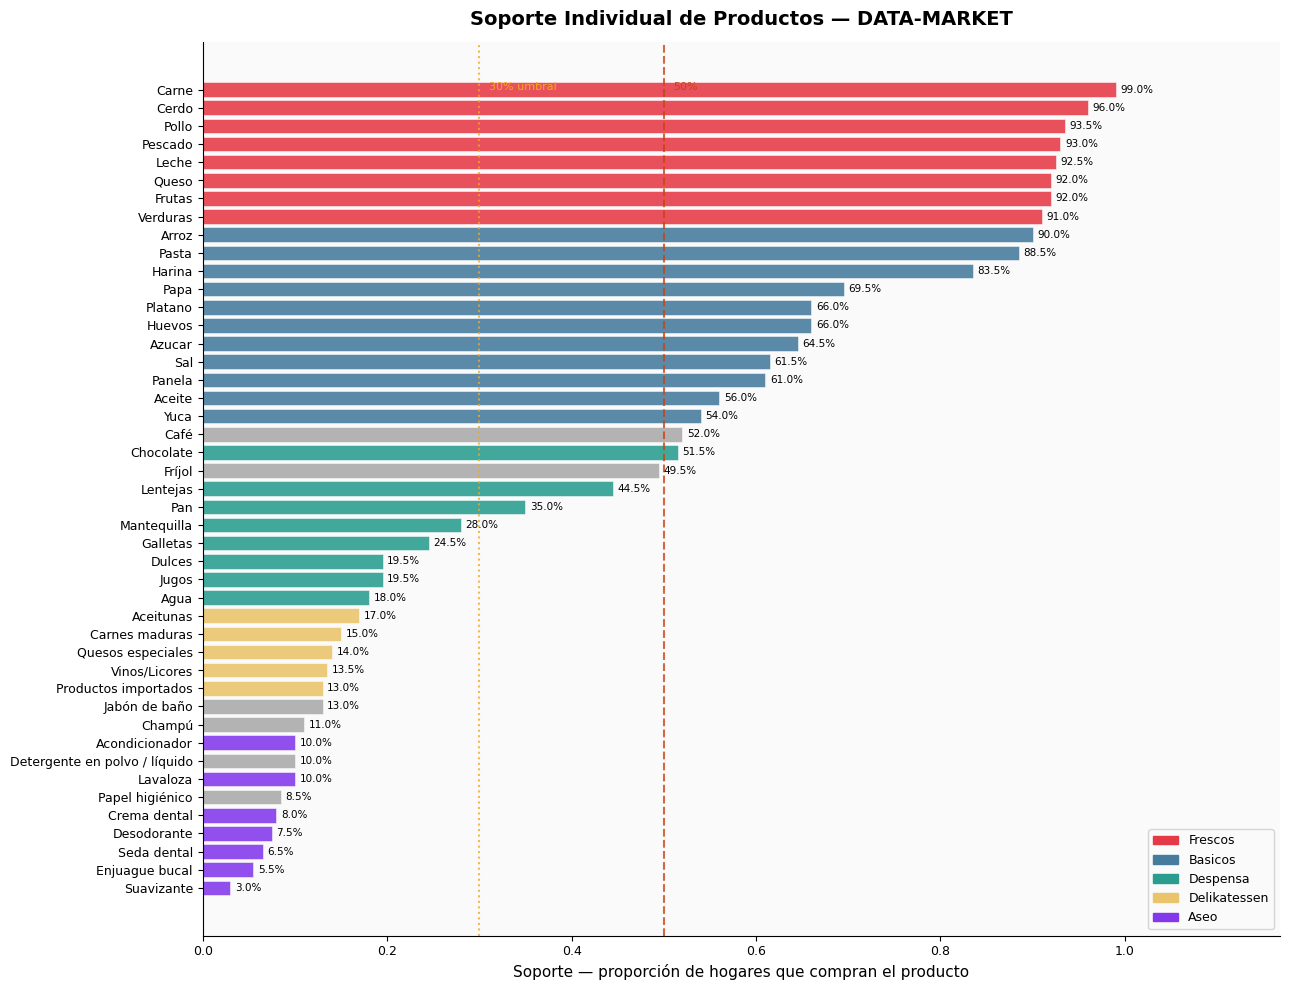

 24/45 productos superan el umbral de soporte 30%
   Producto más comprado : Carne (99.0%)
   Producto menos comprado: Suavizante (3.0%)


In [ ]:
support_series = df_prod.mean().sort_values(ascending=False)
support_series.index = prod_names

colors_list = [ITEM_COLOR.get(p, '#AAAAAA') for p in support_series.index]

fig, ax = plt.subplots(figsize=(13, 10))
bars = ax.barh(support_series.index[::-1], support_series.values[::-1],
               color=colors_list[::-1], alpha=0.88, edgecolor='white', linewidth=0.4)

ax.axvline(0.5, color=PALETTE['primary'], linestyle='--', lw=1.5, alpha=0.8)
ax.axvline(MIN_SUPPORT, color=PALETTE['gold'], linestyle=':', lw=1.5, alpha=0.8)
ax.text(0.5 + 0.01, len(support_series) - 1, '50%', color=PALETTE['primary'], fontsize=8)
ax.text(MIN_SUPPORT + 0.01, len(support_series) - 1, f'{MIN_SUPPORT:.0%} umbral',
        color=PALETTE['gold'], fontsize=8)

for bar, val in zip(bars, support_series.values[::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=7.5)

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in CAT_COLORS.items()]
ax.legend(handles=legend_patches, loc='lower right', framealpha=0.8, fontsize=9)
ax.set_xlabel('Soporte — proporción de hogares que compran el producto')
ax.set_title('Soporte Individual de Productos — DATA-MARKET', pad=12)
ax.set_xlim(0, max(support_series.values) * 1.18)

plt.tight_layout()
plt.savefig('soporte_productos.png', dpi=150, bbox_inches='tight')
plt.show()

n_above = (support_series >= MIN_SUPPORT).sum()
print(f" {n_above}/{len(support_series)} productos superan el umbral de soporte {MIN_SUPPORT:.0%}")
print(f"   Producto más comprado : {support_series.index[0]} ({support_series.iloc[0]:.1%})")
print(f"   Producto menos comprado: {support_series.index[-1]} ({support_series.iloc[-1]:.1%})")

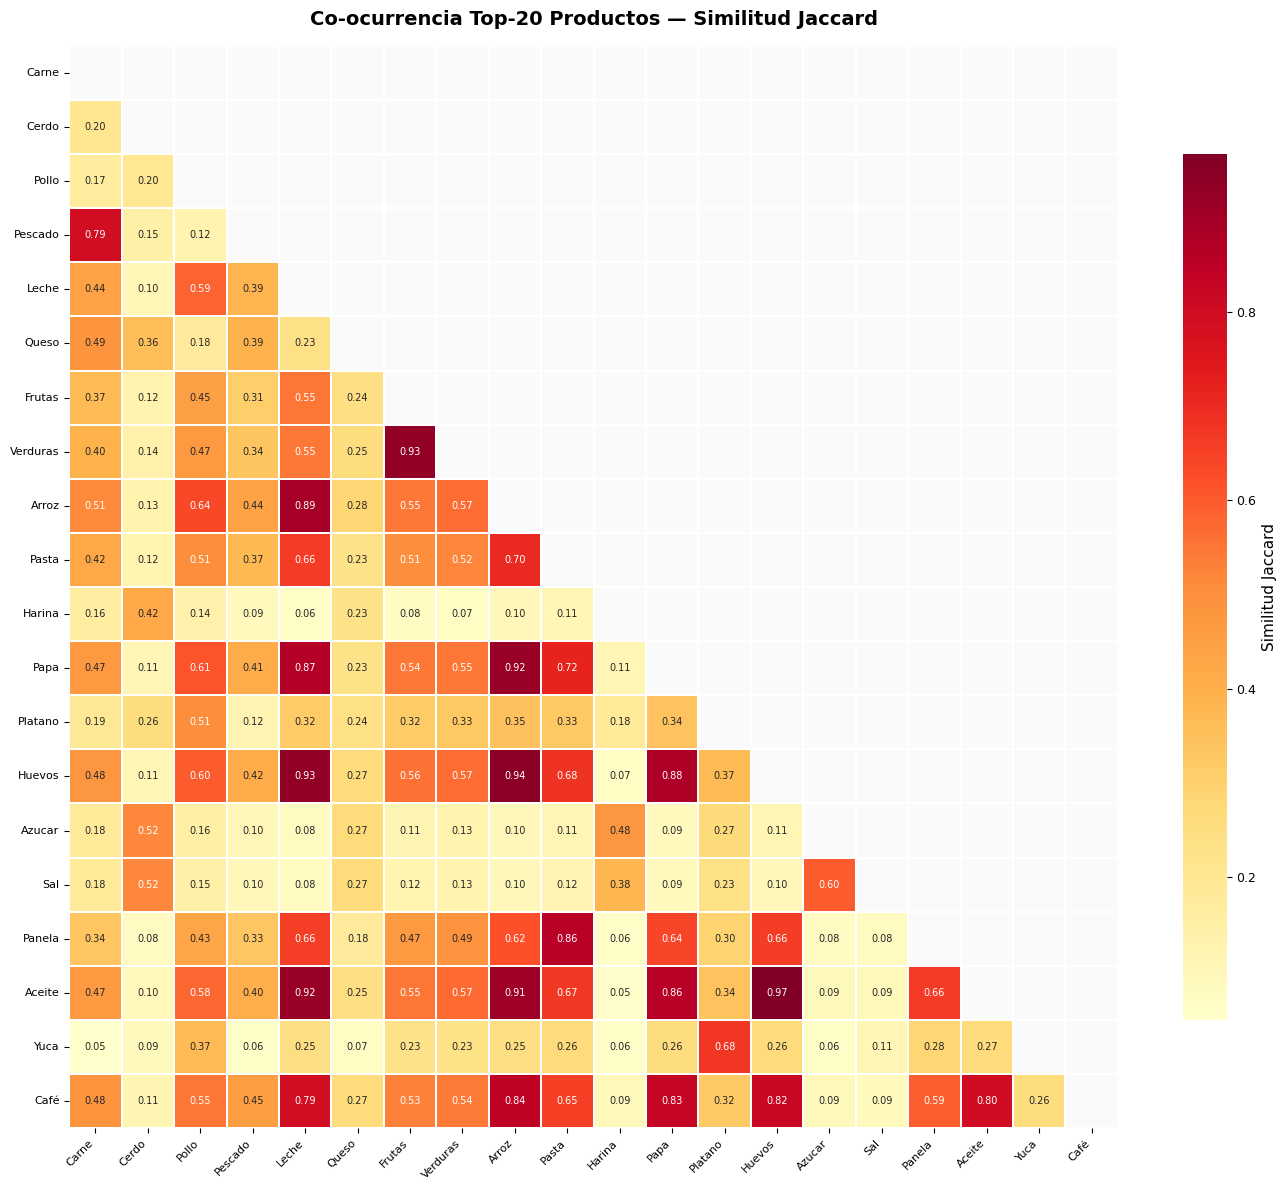

💡 Par con mayor Jaccard: 'Huevos' ↔ 'Aceite'
   Jaccard = 0.968 → se compran juntos en 96.8% de las ocasiones combinadas


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOQUE 6B: HEATMAP DE CO-OCURRENCIA — SIMILITUD JACCARD
#
# Jaccard(A,B) = |TID(A) ∩ TID(B)| / |TID(A) ∪ TID(B)|
#
# Ventaja sobre la correlación de Pearson para datos binarios:
# Jaccard = 1 solo cuando dos productos SIEMPRE se compran juntos.
# Jaccard = 0 cuando nunca coinciden.
# Solo se muestran los top-20 por soporte individual para legibilidad.
# ─────────────────────────────────────────────────────────────────────────────

top20_names = support_series.head(20).index.tolist()
top20_cols  = ['Prod_' + p for p in top20_names]

# Verificar que las columnas existen
top20_cols  = [c for c in top20_cols if c in df_prod.columns]
top20_names = [c.replace('Prod_', '') for c in top20_cols]

co   = df_prod[top20_cols].T.dot(df_prod[top20_cols]).values
diag = np.diag(co)
with np.errstate(invalid='ignore'):
    jaccard = co / (diag[:, None] + diag[None, :] - co)
np.fill_diagonal(jaccard, 0)

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(jaccard, dtype=bool))

sns.heatmap(
    jaccard, mask=mask,
    xticklabels=top20_names, yticklabels=top20_names,
    cmap='YlOrRd', linewidths=0.25, annot=True, fmt='.2f',
    annot_kws={'size': 7}, ax=ax,
    cbar_kws={'label': 'Similitud Jaccard', 'shrink': 0.8}
)
ax.set_title('Co-ocurrencia Top-20 Productos — Similitud Jaccard', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

plt.tight_layout()
plt.savefig('heatmap_coocurrencia.png', dpi=150, bbox_inches='tight')
plt.show()

# Par con mayor afinidad
idx = np.unravel_index(np.argmax(jaccard), jaccard.shape)
print(f"💡 Par con mayor Jaccard: '{top20_names[idx[0]]}' ↔ '{top20_names[idx[1]]}'")
print(f"   Jaccard = {jaccard[idx]:.3f} → se compran juntos en {jaccard[idx]:.1%} de las ocasiones combinadas")

# Conversión al formato horizontal de pyECLAT

In [ ]:
def binary_to_transactions(df_binary, prefix='Prod_'):
    """
    Convierte una matriz one-hot (0/1) al formato horizontal requerido por pyECLAT.

    Parámetros:
        df_binary : DataFrame con columnas Prod_X ∈ {0,1}
        prefix    : prefijo a remover de los nombres de columnas

    Retorna:
        DataFrame con filas=transacciones y columnas=posiciones.
    """
    transactions = []
    for _, row in df_binary.iterrows():
        items = [col.replace(prefix, '') for col in df_binary.columns if row[col] == 1]
        transactions.append(items)

    if not transactions or all(len(t) == 0 for t in transactions):
        return pd.DataFrame()

    max_items = max(len(t) for t in transactions)
    df_horiz  = pd.DataFrame(
        [t + [np.nan] * (max_items - len(t)) for t in transactions]
    )
    return df_horiz

df_transactions = binary_to_transactions(df_prod, prefix='Prod_')

print(f" Formato de transacciones: {df_transactions.shape[0]} filas × {df_transactions.shape[1]} columnas")
print(f"   Promedio de ítems por transacción: {df_transactions.notna().sum(axis=1).mean():.1f}")
print("\nPrimeras 3 transacciones:")
display(df_transactions.head(3))

 Formato de transacciones: 200 filas × 41 columnas
   Promedio de ítems por transacción: 20.2

Primeras 3 transacciones:


,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,Pollo,Leche,Frutas,Verduras,Arroz,Papa,Huevos,Aceite,Café,Chocolate,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Pollo,Leche,Frutas,Verduras,Arroz,Pasta,Papa,Platano,Huevos,Panela,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Pollo,Leche,Frutas,Verduras,Arroz,Papa,Huevos,Aceite,Café,Pan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Ejecución de ECLAT y construcción del DataFrame de itemsets

In [ ]:


eclat_instance = ECLAT(data=df_transactions, verbose=False)

tid_dict, support_dict = eclat_instance.fit(
    min_support     = MIN_SUPPORT,
    min_combination = 1,             # Incluir k=1 (items individuales)
    max_combination = MAX_COMBINATION,
    separator       = SEPARATOR,
    verbose         = True
)

print(f"\n ECLAT completado. Itemsets frecuentes encontrados: {len(support_dict)}")

Combination 1 by 1


24it [00:00, 69.15it/s]


Combination 2 by 2


276it [00:04, 62.35it/s]


Combination 3 by 3


2024it [00:31, 64.66it/s]


 ECLAT completado. Itemsets frecuentes encontrados: 1696


In [ ]:

rows = []
for itemset_str, sup in support_dict.items():
    items_list = [i.strip() for i in itemset_str.split(SEPARATOR)]
    cats = list({get_item_category(i) for i in items_list})
    rows.append({
        'itemset_str' : itemset_str,
        'itemsets'    : frozenset(items_list),
        'support'     : round(sup, 4),
        'count'       : round(sup * N),
        'length'      : len(items_list),
        'categories'  : ' | '.join(sorted(cats)),
        'cross_cat'   : len(cats) > 1,    # ¿El itemset cruza categorías?
    })

results = (
    pd.DataFrame(rows)
    .sort_values('support', ascending=False)
    .reset_index(drop=True)
)

summary_k = (results.groupby('length')
             .agg(
                 total_itemsets = ('support', 'count'),
                 soporte_avg    = ('support', 'mean'),
                 soporte_max    = ('support', 'max'),
                 cross_cat_pct  = ('cross_cat', 'mean'),
             ).round(4))
summary_k.columns = ['Total Itemsets', 'Soporte Promedio', 'Soporte Máximo', '% Cross-Categoría']

print("Resumen por longitud de itemset (k):")
display(summary_k.style.background_gradient(subset=['Soporte Promedio'], cmap='Blues'))

print("\n Top 15 itemsets por soporte:")
display(
    results[['itemset_str', 'support', 'count', 'length', 'categories']].head(15)
    .style
    .background_gradient(subset=['support'], cmap='Blues')
    .format({'support': '{:.1%}', 'count': '{:.0f}'})
)

Resumen por longitud de itemset (k):


,Total Itemsets,Soporte Promedio,Soporte Máximo,% Cross-Categoría
length,,,,
1,24,0.725800,0.990000,0.000000
2,252,0.573900,0.955000,0.821400
3,1420,0.499800,0.915000,0.969700



 Top 15 itemsets por soporte:


,itemset_str,support,count,length,categories
0,Arroz,99.0%,198,1,Basicos
1,Jabón de baño,96.0%,192,1,Otro
2,Arroz & Jabón de baño,95.5%,191,2,Basicos | Otro
3,Papel higiénico & Arroz,93.5%,187,2,Basicos | Otro
4,Papel higiénico,93.5%,187,1,Otro
5,Huevos & Arroz,93.0%,186,2,Basicos
6,Huevos,93.0%,186,1,Basicos
7,Detergente en polvo / líquido,92.5%,185,1,Otro
8,Papa,92.0%,184,1,Basicos
9,Detergente en polvo / líquido & Arroz,92.0%,184,2,Basicos | Otro


# Generación de Reglas de Asociación (con 5 métricas)


In [ ]:


rules = mlx_rules(
    results[['itemsets', 'support']],
    metric        = 'confidence',
    min_threshold = MIN_CONFIDENCE,
    num_itemsets  = len(results)
)

if len(rules) == 0:
    print("⚠️  Ninguna regla superó el umbral de confianza.")
    print(f"   Considera bajar MIN_CONFIDENCE (actual: {MIN_CONFIDENCE:.0%}) o MIN_SUPPORT.")
else:
    # Columnas legibles
    rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ' + '.join(sorted(x)))
    rules['consequents_str'] = rules['consequents'].apply(lambda x: ' + '.join(sorted(x)))
    rules['rule']            = rules['antecedents_str'] + '  →  ' + rules['consequents_str']
    rules['ant_size']        = rules['antecedents'].apply(len)
    rules['cons_size']       = rules['consequents'].apply(len)

    def zhang_metric(row):
        p_ab = row['support']
        p_a  = row['antecedent support']
        p_b  = row['consequent support']
        num  = p_ab - p_a * p_b
        den  = max(p_ab * (1 - p_a), p_a * (p_b - p_ab))
        return num / den if den != 0 else 0

    rules['zhang'] = rules.apply(zhang_metric, axis=1)

    rules['business_score'] = (
        0.35 * rules['support'] +
        0.30 * rules['confidence'] +
        0.25 * (rules['lift'] / rules['lift'].max()) +
        0.10 * rules['leverage'].clip(0)
    )

    rules_sorted = rules.sort_values('lift', ascending=False).reset_index(drop=True)

    print(f"✅ Reglas generadas: {len(rules_sorted)}")
    print(f"   Filtros: soporte ≥ {MIN_SUPPORT:.0%} | confianza ≥ {MIN_CONFIDENCE:.0%}")

    display(
        rules_sorted[['rule', 'support', 'confidence', 'lift',
                       'conviction', 'leverage', 'zhang', 'business_score']]
        .head(20)
        .style
        .background_gradient(subset=['lift'],       cmap='Reds')
        .background_gradient(subset=['confidence'], cmap='Blues')
        .background_gradient(subset=['zhang'],      cmap='Greens')
        .format({
            'support'        : '{:.1%}',
            'confidence'     : '{:.1%}',
            'lift'           : '{:.3f}',
            'conviction'     : '{:.3f}',
            'leverage'       : '{:.4f}',
            'zhang'          : '{:.3f}',
            'business_score' : '{:.4f}',
        })
    )

✅ Reglas generadas: 6570
   Filtros: soporte ≥ 30% | confianza ≥ 60%


,rule,support,confidence,lift,conviction,leverage,zhang,business_score
0,Carne + Desodorante → Pescado,37.5%,90.4%,2.031,5.758,0.1903,0.868,0.6714
1,Pescado → Carne + Desodorante,37.5%,84.3%,2.031,3.719,0.1903,0.914,0.6531
2,Pescado → Carne + Lavaloza,39.5%,88.8%,1.995,4.940,0.1970,0.899,0.6698
3,Carne + Lavaloza → Pescado,39.5%,88.8%,1.995,4.940,0.1970,0.899,0.6698
4,Café + Carne → Pescado,39.0%,88.6%,1.992,4.884,0.1942,0.889,0.6671
5,Pescado → Café + Carne,39.0%,87.6%,1.992,4.531,0.1942,0.897,0.6641
6,Carne + Detergente en polvo / líquido → Pescado,41.5%,88.3%,1.984,4.743,0.2058,0.936,0.6750
7,Pescado → Carne + Detergente en polvo / líquido,41.5%,93.3%,1.984,7.862,0.2058,0.894,0.6899
8,Pescado → Carne + Papel higiénico,41.0%,92.1%,1.960,6.739,0.2008,0.883,0.6813
9,Carne + Papel higiénico → Pescado,41.0%,87.2%,1.960,4.348,0.2008,0.924,0.6666


#  Visualizaciones de Reglas

In [ ]:


fig = px.scatter(
    rules_sorted.head(100),
    x    = 'support',
    y    = 'confidence',
    size = 'lift',
    color= 'lift',
    color_continuous_scale = 'YlOrRd',
    hover_data = ['rule', 'lift', 'leverage', 'zhang', 'conviction'],
    labels = {
        'support'   : 'Soporte',
        'confidence': 'Confianza',
        'lift'      : 'Lift',
    },
    title    = 'Mapa de Reglas — Soporte × Confianza (tamaño = Lift)',
    template = 'plotly_white',
)
fig.add_hline(y=0.75, line_dash='dash', line_color='gray',
              annotation_text='Conf. 75%', annotation_position='bottom right')
fig.add_vline(x=0.40, line_dash='dot',  line_color='gray',
              annotation_text='Sup. 40%', annotation_position='top left')
fig.update_traces(marker=dict(line=dict(width=0.5, color='white')))
fig.update_layout(height=550, coloraxis_colorbar=dict(title='Lift'))
fig.show()

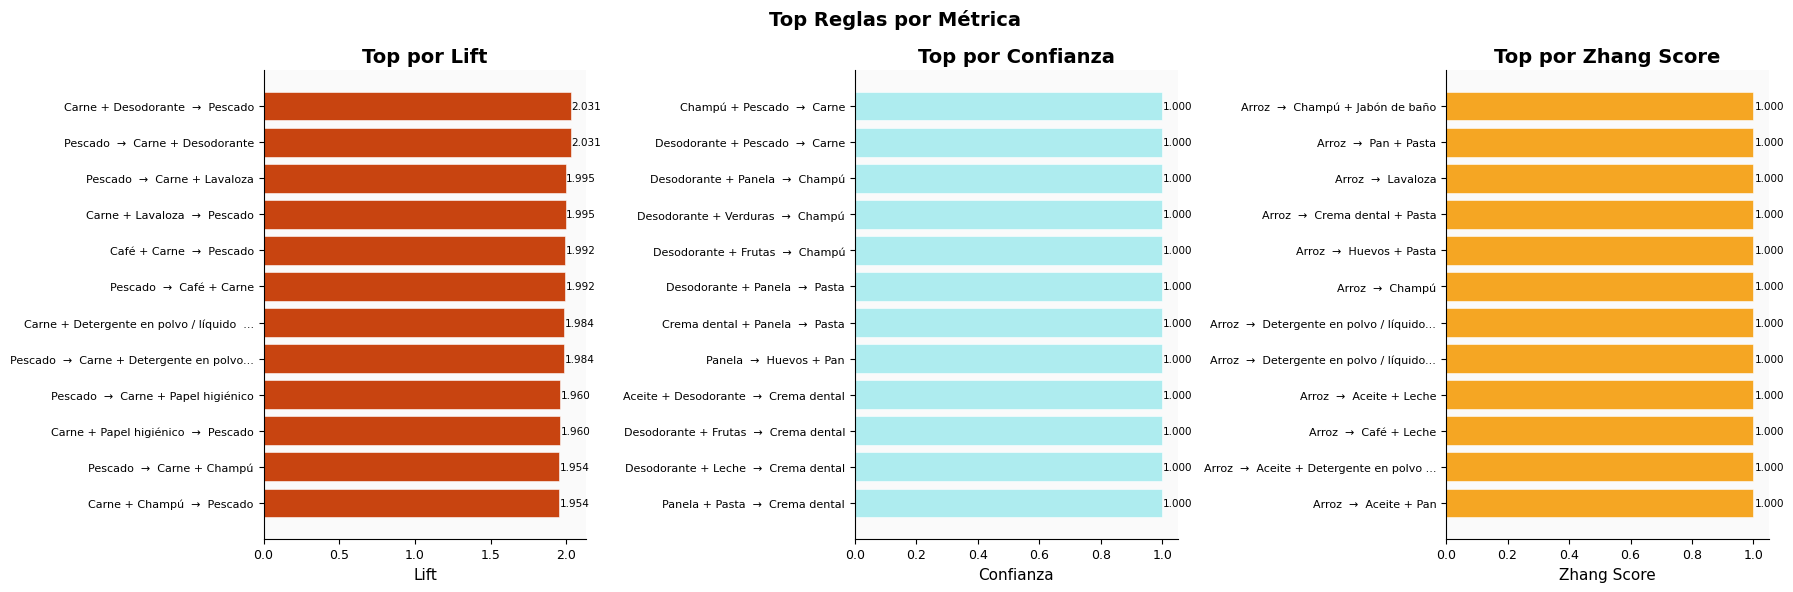

In [ ]:


top_n = min(12, len(rules_sorted))
top_rules = rules_sorted.head(top_n).copy()
top_rules['rule_short'] = top_rules['rule'].apply(lambda r: r if len(r) < 40 else r[:37] + '...')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Top Reglas por Métrica', fontsize=14, fontweight='bold')

metrics = [
    ('lift',       'Lift',        PALETTE['primary']),
    ('confidence', 'Confianza',   PALETTE['accent']),
    ('zhang',      'Zhang Score', PALETTE['gold']),
]

for ax, (metric, label, color) in zip(axes, metrics):
    ranked = rules_sorted.nlargest(top_n, metric)
    ranked['rule_short'] = ranked['rule'].apply(
        lambda r: r if len(r) < 42 else r[:39] + '...'
    )
    bars = ax.barh(range(len(ranked)), ranked[metric].values[::-1],
                   color=color, edgecolor='white', linewidth=0.4)
    ax.set_yticks(range(len(ranked)))
    ax.set_yticklabels(ranked['rule_short'].values[::-1], fontsize=8)
    for bar, val in zip(bars, ranked[metric].values[::-1]):
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=7.5)
    ax.set_title(f'Top por {label}')
    ax.set_xlabel(label)

plt.tight_layout()
plt.savefig('top_reglas.png', dpi=150, bbox_inches='tight')
plt.show()

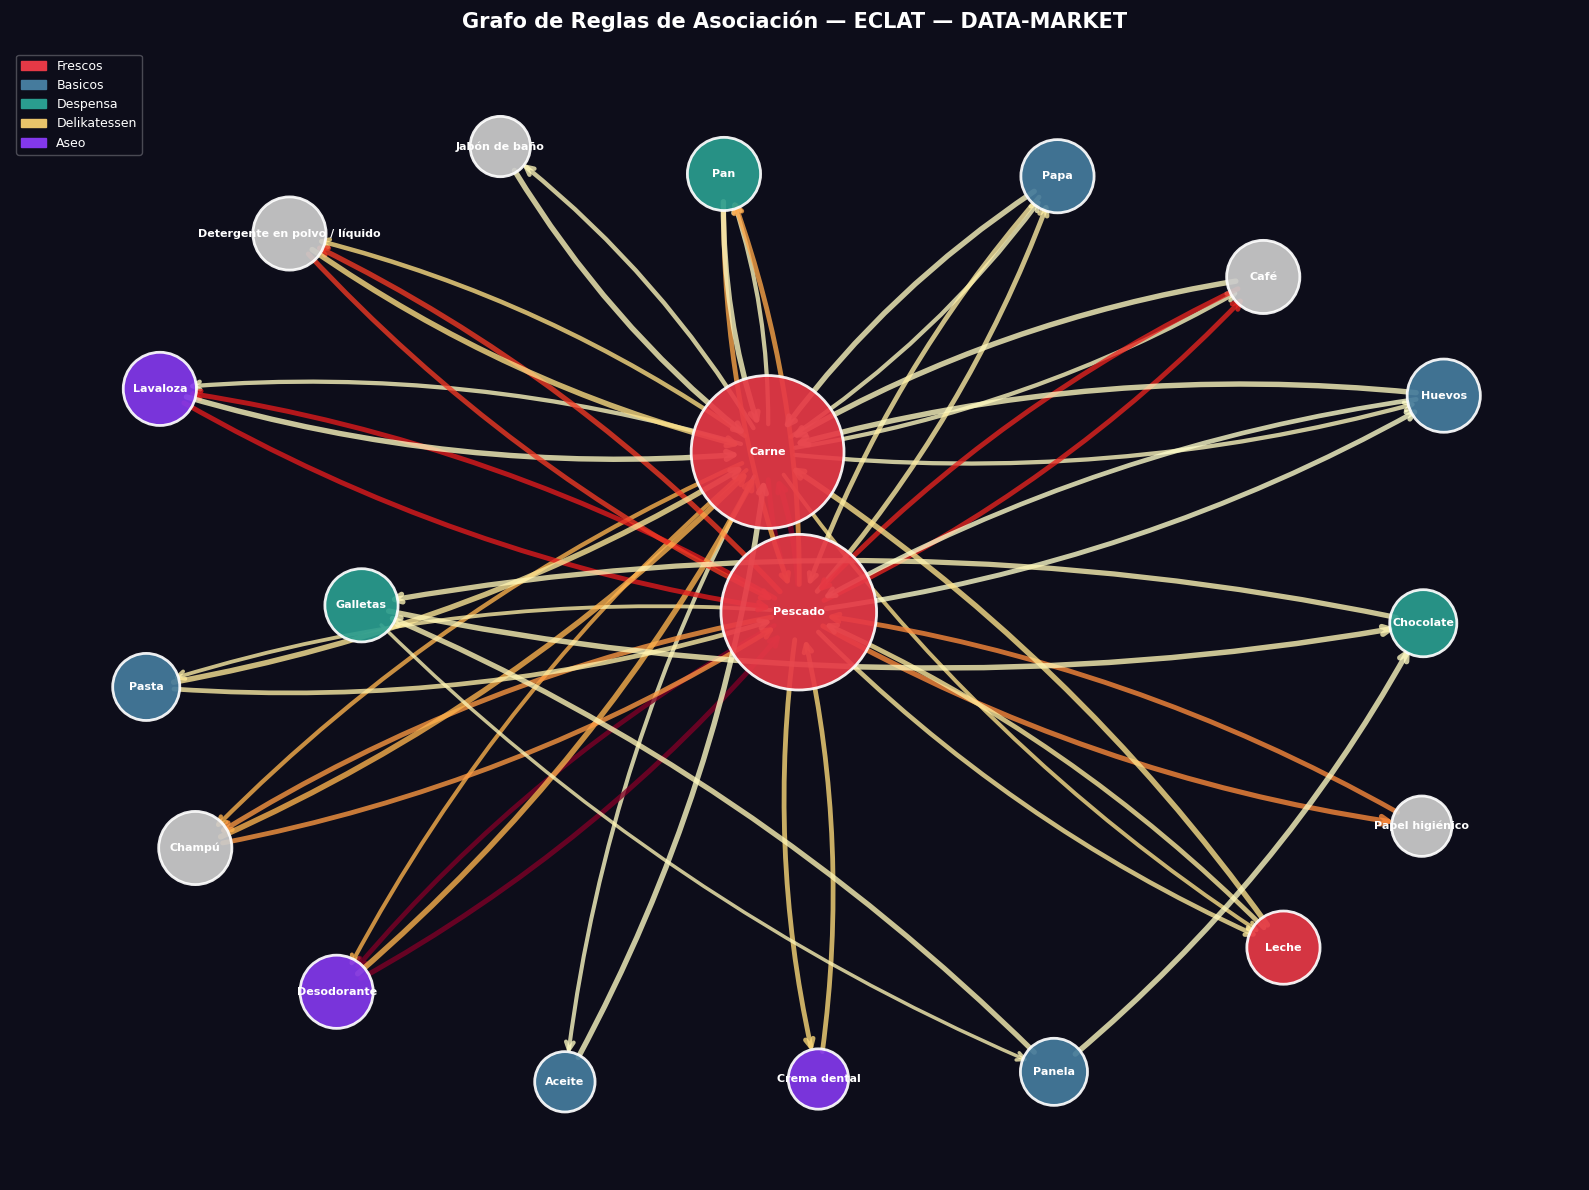

Nodos: 19 | Aristas: 54

🔗 Productos más centrales en el grafo (hubs de reglas):
   Pescado                        — centralidad: 1.444 | cat: Frescos
   Carne                          — centralidad: 1.389 | cat: Frescos
   Desodorante                    — centralidad: 0.222 | cat: Aseo
   Lavaloza                       — centralidad: 0.222 | cat: Aseo
   Café                           — centralidad: 0.222 | cat: Otro


In [ ]:

rules_graph = rules_sorted[
    (rules_sorted['lift']       >= 1.05) &
    (rules_sorted['confidence'] >= MIN_CONFIDENCE)
].head(50)

G = nx.DiGraph()
for _, row in rules_graph.iterrows():
    for ant in row['antecedents']:
        for cons in row['consequents']:
            if G.has_edge(ant, cons):
                # Si ya existe, actualizar con el lift mayor
                G[ant][cons]['weight'] = max(G[ant][cons]['weight'], row['confidence'])
                G[ant][cons]['lift']   = max(G[ant][cons]['lift'], row['lift'])
            else:
                G.add_edge(ant, cons, weight=row['confidence'], lift=row['lift'])

if G.number_of_nodes() == 0:
    print("⚠️  Sin aristas para el grafo con los filtros actuales.")
else:
    degree_c    = nx.degree_centrality(G)
    pos         = nx.spring_layout(G, k=2.8, seed=42, iterations=80)
    edge_lifts  = [d['lift']   for _, _, d in G.edges(data=True)]
    edge_widths = [d['weight'] for _, _, d in G.edges(data=True)]

    fig, ax = plt.subplots(figsize=(16, 12))
    ax.set_facecolor('#0D0D1A')
    fig.set_facecolor('#0D0D1A')

    nx.draw_networkx_edges(
        G, pos, ax=ax,
        width            = [w * 4 for w in edge_widths],
        edge_color       = edge_lifts,
        edge_cmap        = plt.cm.YlOrRd,
        arrows           = True,
        arrowstyle       = '->',
        arrowsize        = 14,
        connectionstyle  = 'arc3,rad=0.10',
        alpha            = 0.78,
        min_source_margin= 20,
        min_target_margin= 20,
    )

    node_sizes  = [degree_c[n] * 8000 + 1000 for n in G.nodes()]
    node_colors = [ITEM_COLOR.get(n, '#CCCCCC') for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes,
                           node_color=node_colors, alpha=0.92,
                           linewidths=2, edgecolors='white')
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8,
                            font_color='white', font_weight='bold')

    legend_patches = [mpatches.Patch(color=v, label=k) for k, v in CAT_COLORS.items()]
    ax.legend(handles=legend_patches, loc='upper left',
              framealpha=0.25, facecolor='#0D0D1A',
              edgecolor='white', labelcolor='white', fontsize=9)
    ax.set_title('Grafo de Reglas de Asociación — ECLAT — DATA-MARKET',
                 color='white', fontsize=15, fontweight='bold', pad=15)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('grafo_reglas.png', dpi=150, bbox_inches='tight', facecolor='#0D0D1A')
    plt.show()
    print(f"Nodos: {G.number_of_nodes()} | Aristas: {G.number_of_edges()}")

    top_hubs = sorted(degree_c.items(), key=lambda x: x[1], reverse=True)[:5]
    print("\n🔗 Productos más centrales en el grafo (hubs de reglas):")
    for prod, centrality in top_hubs:
        print(f"   {prod:30s} — centralidad: {centrality:.3f} | cat: {get_item_category(prod)}")

# Análisis Segmentado por Estrato
**¿cambia el estrato el patrón de compra?**

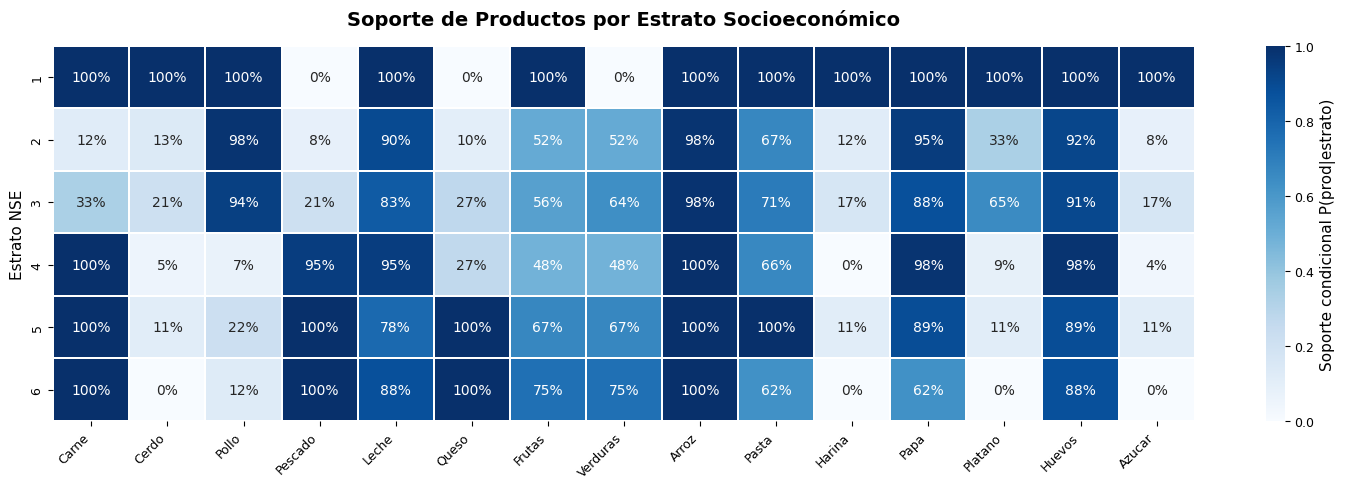

📊 Productos con mayor variación de soporte entre estratos:
Pescado      0.489
Pollo        0.460
Queso        0.446
Carne        0.406
Platano      0.390
Harina       0.382
Azucar       0.380
Cerdo        0.374

💡 Alta variabilidad = el producto es discriminador socioeconómico.
   Diseñar promociones diferenciadas por estrato para estos ítems.


In [ ]:


top15_names = support_series.head(15).index.tolist()
top15_cols  = ['Prod_' + p for p in top15_names if 'Prod_' + p in df_prod.columns]
top15_names = [c.replace('Prod_', '') for c in top15_cols]

strat_support = df_full.groupby('Estrato')[top15_cols].mean()
strat_support.columns = top15_names

fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(
    strat_support, annot=True, fmt='.0%', cmap='Blues',
    linewidths=0.3, ax=ax, cbar_kws={'label': 'Soporte condicional P(prod|estrato)'}
)
ax.set_title('Soporte de Productos por Estrato Socioeconómico', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Estrato NSE')
plt.tight_layout()
plt.savefig('soporte_por_estrato.png', dpi=150, bbox_inches='tight')
plt.show()

# Identificar productos con mayor variabilidad entre estratos (candidatos a segmentación)
strat_variability = strat_support.std().sort_values(ascending=False)
print("📊 Productos con mayor variación de soporte entre estratos:")
print(strat_variability.head(8).apply(lambda v: f"  {v:.3f}").to_string())
print("\n💡 Alta variabilidad = el producto es discriminador socioeconómico.")
print("   Diseñar promociones diferenciadas por estrato para estos ítems.")

In [ ]:

def eclat_y_reglas_segmento(df_full, col_seg, val_seg, prod_cols,
                             base_min_sup=0.30, min_conf=0.55, max_comb=2):
    """
    Ejecuta pyECLAT + generación de reglas sobre un subconjunto demográfico.

    Retorna:
        df_items : DataFrame de itemsets frecuentes (o None si n < 5)
        df_rules : DataFrame de reglas (o None)
        n        : tamaño del subconjunto
    """
    mask   = df_full[col_seg] == val_seg
    n      = mask.sum()
    if n < 5:
        return None, None, n

    subset = df_full[mask][prod_cols].astype(int).reset_index(drop=True)
    df_h   = binary_to_transactions(subset, prefix='Prod_')

    if df_h.empty:
        return None, None, n

    adaptive_min_sup = max(base_min_sup, 3 / max(n, 1))

    eclat_seg = ECLAT(data=df_h, verbose=False)
    tid_s, sup_s = eclat_seg.fit(
        min_support=adaptive_min_sup, min_combination=1,
        max_combination=max_comb, separator=' & ', verbose=False
    )

    rows_seg = []
    for key, sup in sup_s.items():
        items_list = [i.strip() for i in key.split(' & ')]
        rows_seg.append({
            'itemset_str': key, 'itemsets': frozenset(items_list),
            'support': round(sup, 4), 'count': round(sup * n),
            'length': len(items_list)
        })

    if not rows_seg:
        return None, None, n

    df_items = pd.DataFrame(rows_seg).sort_values('support', ascending=False).reset_index(drop=True)

    df_rules = None
    try:
        raw_rules = mlx_rules(
            df_items[['itemsets', 'support']],
            metric='confidence', min_threshold=min_conf,
            num_itemsets=len(df_items)
        )
        if len(raw_rules) > 0:
            raw_rules['rule'] = (
                raw_rules['antecedents'].apply(lambda x: ' + '.join(sorted(x))) +
                '  →  ' +
                raw_rules['consequents'].apply(lambda x: ' + '.join(sorted(x)))
            )
            df_rules = raw_rules.sort_values('lift', ascending=False).reset_index(drop=True)
    except Exception:
        pass

    return df_items, df_rules, n


print("=" * 65)
print("  ECLAT SEGMENTADO POR ESTRATO — Reglas de Asociación")
print("=" * 65)

resultados_estrato = {}
for estrato in sorted(df_meta['Estrato'].unique()):
    df_i, df_r, n_seg = eclat_y_reglas_segmento(
        df_full, 'Estrato', estrato, PROD_COLS,
        base_min_sup=0.20,
        min_conf=0.55
    )
    resultados_estrato[estrato] = {'items': df_i, 'rules': df_r, 'n': n_seg}

    print(f"\n▶ Estrato {estrato}  (n={n_seg})")
    if df_r is None or len(df_r) == 0:
        print("  — Sin reglas suficientes (muestra pequeña o umbral no alcanzado)")
    else:
        print(f"  Reglas encontradas: {len(df_r)}")
        for _, row in df_r.head(4).iterrows():
            print(f"  [{row['lift']:.2f}x] {row['rule']}  (conf={row['confidence']:.0%})")

  ECLAT SEGMENTADO POR ESTRATO — Reglas de Asociación

▶ Estrato 1  (n=1)
  — Sin reglas suficientes (muestra pequeña o umbral no alcanzado)

▶ Estrato 2  (n=60)
  Reglas encontradas: 304
  [3.00x] Yuca  →  Platano  (conf=100%)
  [3.00x] Platano  →  Yuca  (conf=80%)
  [1.94x] Verduras  →  Frutas  (conf=100%)
  [1.94x] Frutas  →  Verduras  (conf=100%)

▶ Estrato 3  (n=66)
  Reglas encontradas: 495
  [2.50x] Queso  →  Carne  (conf=83%)
  [2.50x] Carne  →  Queso  (conf=68%)
  [1.65x] Galletas  →  Chocolate  (conf=88%)
  [1.65x] Chocolate  →  Galletas  (conf=80%)

▶ Estrato 4  (n=56)
  Reglas encontradas: 406
  [2.07x] Verduras  →  Frutas  (conf=100%)
  [2.07x] Frutas  →  Verduras  (conf=100%)
  [1.87x] Galletas  →  Chocolate  (conf=93%)
  [1.87x] Chocolate  →  Galletas  (conf=100%)

▶ Estrato 5  (n=9)
  Reglas encontradas: 804
  [1.50x] Verduras  →  Frutas  (conf=100%)
  [1.50x] Frutas  →  Verduras  (conf=100%)
  [1.50x] Chocolate  →  Galletas  (conf=100%)
  [1.50x] Galletas  →  Chocolate

In [ ]:

prod_list = []
for estrato, data in resultados_estrato.items():
    if data['items'] is None:
        continue
    singles = data['items'][data['items']['length'] == 1].head(8)
    for _, row in singles.iterrows():
        prod = list(row['itemsets'])[0]
        prod_list.append({
            'Estrato'  : f"E{estrato}",
            'Producto' : prod,
            'Soporte'  : row['support'],
            'Categoría': get_item_category(prod),
        })

plot_df = pd.DataFrame(prod_list)

if not plot_df.empty:
    fig = px.bar(
        plot_df,
        x         = 'Soporte',
        y         = 'Producto',
        color     = 'Estrato',
        barmode   = 'group',
        facet_col = None,
        orientation='h',
        hover_data= ['Categoría'],
        title     = 'Soporte de Productos Frecuentes por Estrato NSE',
        template  = 'plotly_white',
        color_discrete_sequence = px.colors.qualitative.Set2,
    )
    fig.update_layout(height=600, yaxis={'categoryorder': 'total ascending'})
    fig.show()

# Análisis Segmentado por Grupo Etario

Distribución de grupos etarios:
  Joven (18-25)             █████████████████████ 85 (42%)
  Adulto joven (26-35)      █████████ 38 (19%)
  Adulto (36-50)            ████████ 34 (17%)
  Senior (51+)              ██████████ 43 (22%)


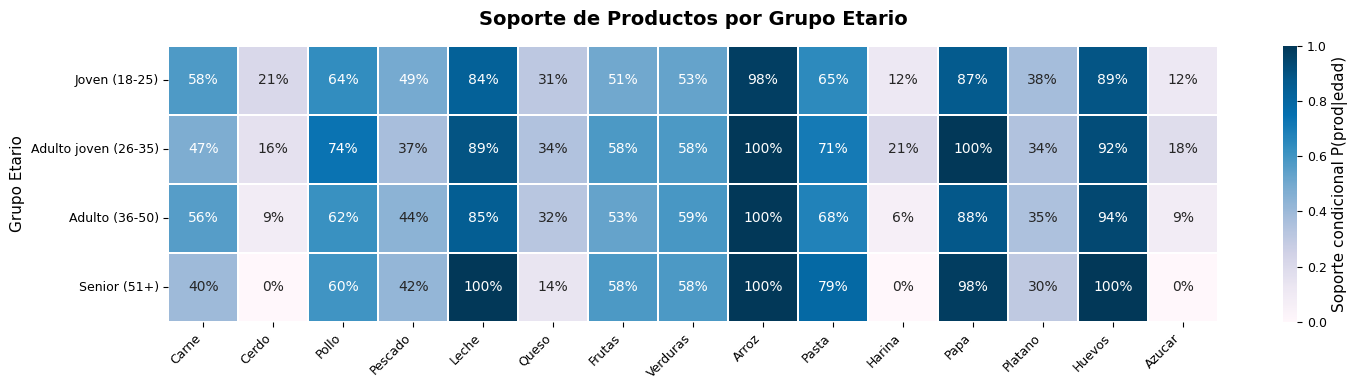

In [ ]:


import re

def extract_lower_age(age_str):
    if isinstance(age_str, str):
        match = re.match(r'(\d+)', age_str)
        if match:
            return int(match.group(1))
    return np.nan

df_full['Edad_num'] = df_full['Edad'].apply(extract_lower_age)

df_full['Grupo_Edad'] = pd.cut(
    df_full['Edad_num'],
    bins   = [0, 26, 36, 51, 120],
    labels = ['Joven (18-25)', 'Adulto joven (26-35)', 'Adulto (36-50)', 'Senior (51+)'],
    right  = False
)

edad_dist = df_full['Grupo_Edad'].value_counts().sort_index()
print("Distribución de grupos etarios:")
for grupo, count in edad_dist.items():
    bar = '█' * int(count / N * 50)
    print(f"  {str(grupo):25s} {bar} {count} ({count/N:.0%})")

edad_support = df_full.groupby('Grupo_Edad', observed=True)[top15_cols].mean()
edad_support.columns = top15_names

fig, ax = plt.subplots(figsize=(15, 4))
sns.heatmap(
    edad_support, annot=True, fmt='.0%', cmap='PuBu',
    linewidths=0.3, ax=ax,
    cbar_kws={'label': 'Soporte condicional P(prod|edad)'}
)
ax.set_title('Soporte de Productos por Grupo Etario', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Grupo Etario')
plt.tight_layout()
plt.savefig('soporte_por_edad.png', dpi=150, bbox_inches='tight')
plt.show()

# Análisis Cruzado: Canal × Demografía

In [ ]:

canal_profiles = {}
for c_col, c_name in CANAL_LABELS.items():
    if c_col not in df_canal.columns:
        continue
    mask = df_canal[c_col] == 1
    if mask.sum() < 3:
        continue
    canal_profiles[c_name] = df_prod[mask].mean()

canal_df         = pd.DataFrame(canal_profiles).T
canal_df.columns = [c.replace('Prod_', '') for c in canal_df.columns]

top20_for_canal = support_series.head(20).index.tolist()
canal_df_top    = canal_df[[c for c in top20_for_canal if c in canal_df.columns]]

fig = px.imshow(
    canal_df_top,
    color_continuous_scale = 'Blues',
    text_auto              = '.0%',
    labels                 = dict(x='Producto', y='Canal', color='Soporte cond.'),
    title                  = 'Perfil de Compra por Canal — Top 20 Productos',
    template               = 'plotly_white',
    aspect                 = 'auto',
)
fig.update_layout(height=380)
fig.update_xaxes(tickangle=45)
fig.show()

print("\n🔍 Producto TOP diferenciador por canal (mayor soporte condicional):")
for canal in canal_df_top.index:
    top_prod = canal_df_top.loc[canal].idxmax()
    sup_val  = canal_df_top.loc[canal].max()
    print(f"  {canal:25s} → {top_prod:20s} ({sup_val:.0%})")


🔍 Producto TOP diferenciador por canal (mayor soporte condicional):
  Hard Discount             → Arroz                (99%)
  Grandes Superficies       → Arroz                (99%)
  Tienda de Barrio          → Arroz                (94%)
  Plaza de Mercado          → Arroz                (95%)
  App / Domicilios          → Carne                (100%)
